In [ ]:

from google.colab import files

uploaded = files.upload()



Saving archive (17).zip to archive (17) (1).zip


## Imports & configuration

In [ ]:

import os
import re
import shutil
import hashlib
import zipfile
import math

import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report,
)
import matplotlib.pyplot as plt
import matplotlib.cm as cm

RANDOM_SEED = 42
IMG_SIZE = (224, 224)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


## Extract dataset

In [ ]:

ZIP_PATH = "/content/archive (17).zip"
EXTRACT_DIR = "/content/brain_ct_extracted"
OUTPUT_DIR = "/content/patient_level_dataset"

MANIFEST_PATH = "/content/patient_level_split_manifest.csv"
CASE_MANIFEST_PATH = "/content/case_level_split_manifest.csv"

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully.")
print("Location:", EXTRACT_DIR)

image_files = [
    os.path.join(root, file)
    for root, _, files_in_dir in os.walk(EXTRACT_DIR)
    for file in files_in_dir
    if file.lower().endswith(IMAGE_EXTENSIONS)
]
print("Total image files found:", len(image_files))



Dataset extracted successfully.
Location: /content/brain_ct_extracted
Total image files found: 2515


## Parse class and patient (case) ID

In [ ]:

def extract_class(path):

    parts = os.path.normpath(path).split(os.sep)
    for part in parts:
        if part.lower() in ["normal", "stroke"]:
            return part.capitalize()
    return None


def extract_case_id(filename):

    match = re.match(r"^\s*(\d+)", filename)
    return match.group(1) if match else None


records = []
for path in image_files:
    filename = os.path.basename(path)
    class_name = extract_class(path)
    case_id = extract_case_id(filename)
    if class_name is None or case_id is None:
        continue
    records.append({
        "image_path": path, "filename": filename,
        "class": class_name, "case_id": case_id,
    })

df = pd.DataFrame(records)
print("Valid image records:", len(df))
print(df.groupby("class")["case_id"].nunique())



Valid image records: 2515
class
Normal    51
Stroke    31
Name: case_id, dtype: int64


In [ ]:

def calculate_sha256(filepath):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(1024 * 1024)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


df["sha256"] = df["image_path"].apply(calculate_sha256)
df["duplicate_of"] = ""
first_occurrence = {}
for index, row in df.iterrows():
    h = row["sha256"]
    if h in first_occurrence:
        df.at[index, "duplicate_of"] = first_occurrence[h]
    else:
        first_occurrence[h] = row["image_path"]

df_unique = df[df["duplicate_of"] == ""].copy()
print("Unique images:", len(df_unique))
print("Unique patients:", df_unique[["class", "case_id"]].drop_duplicates().shape[0])



Unique images: 2501
Unique patients: 82


## Patient-level train / validation / test split

In [ ]:

case_df = df_unique[["class", "case_id"]].drop_duplicates().reset_index(drop=True)

train_val_cases, test_cases = train_test_split(
    case_df, test_size=17, stratify=case_df["class"], random_state=RANDOM_SEED,
)
train_cases, val_cases = train_test_split(
    train_val_cases, test_size=8, stratify=train_val_cases["class"], random_state=RANDOM_SEED,
)

print("Training patients   :", len(train_cases))
print("Validation patients :", len(val_cases))
print("Testing patients    :", len(test_cases))

train_case_set = set(zip(train_cases["class"], train_cases["case_id"]))
val_case_set = set(zip(val_cases["class"], val_cases["case_id"]))
test_case_set = set(zip(test_cases["class"], test_cases["case_id"]))


def assign_split(row):
    key = (row["class"], row["case_id"])
    if key in train_case_set:
        return "Train"
    if key in val_case_set:
        return "Validation"
    if key in test_case_set:
        return "Test"
    return None


df_unique["corrected_split"] = df_unique.apply(assign_split, axis=1)

train_ids = set(train_cases["case_id"])
val_ids = set(val_cases["case_id"])
test_ids = set(test_cases["case_id"])
assert not (train_ids & val_ids) and not (train_ids & test_ids) and not (val_ids & test_ids)
print("Patient overlap check passed — zero overlap between splits.")

train_df = df_unique[df_unique["corrected_split"] == "Train"].reset_index(drop=True)
val_df = df_unique[df_unique["corrected_split"] == "Validation"].reset_index(drop=True)
test_df = df_unique[df_unique["corrected_split"] == "Test"].reset_index(drop=True)
print("Train:", len(train_df), " Validation:", len(val_df), " Test:", len(test_df))


Training patients   : 57
Validation patients : 8
Testing patients    : 17
Patient overlap check passed — zero overlap between splits.
Train: 1761  Validation: 221  Test: 519


## Verify zero patient overlap between splits

In [ ]:
train_ids = set(train_cases["case_id"])
val_ids = set(val_cases["case_id"])
test_ids = set(test_cases["case_id"])

print("Train ∩ Validation:", train_ids & val_ids)
print("Train ∩ Test:      ", train_ids & test_ids)
print("Validation ∩ Test: ", val_ids & test_ids)

Train ∩ Validation: set()
Train ∩ Test:       set()
Validation ∩ Test:  set()


## Preprocessing pipeline

In [ ]:

def resize_image(image, size=(224, 224)):
    return cv2.resize(image, size, interpolation=cv2.INTER_AREA)


def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    gray = image[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    enhanced = clahe.apply(gray)
    return np.stack([enhanced] * 3, axis=-1)


def apply_gamma_correction(image, gamma=1.2):
    img_float = image.astype(np.float32) / 255.0
    gamma_corrected = np.power(img_float, gamma)
    return (gamma_corrected * 255.0).astype(np.uint8)


def normalize_image(image):
    return image.astype(np.float32) / 255.0


def preprocess_pipeline(image):
    """Resize -> CLAHE -> gamma correction (gamma=1.2) -> normalize to [0,1]."""
    resized = resize_image(image)
    clahe_img = apply_clahe(resized)
    gamma_img = apply_gamma_correction(clahe_img, gamma=1.2)
    normalized = normalize_image(gamma_img)
    return resized, clahe_img, gamma_img, normalized



## Augmentation

In [ ]:

train_augmenter = keras.Sequential([
    layers.RandomRotation(factor=8 / 360, fill_mode="constant"),
    layers.RandomZoom(height_factor=(-0.15, 0.15), fill_mode="constant"),
    layers.RandomContrast(factor=0.2),
], name="online_augmentation")


def _load_and_preprocess(path, label):
    def _run(p):
        raw = cv2.imread(p.numpy().decode("utf-8"))
        raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        _, _, _, normalized = preprocess_pipeline(raw)
        return normalized.astype(np.float32)

    image = tf.py_function(func=_run, inp=[path], Tout=tf.float32)
    image.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    return image, label


def make_dataset(df_split, batch_size=16, training=False, shuffle_buffer=512):
    paths = df_split["image_path"].values
    labels = (df_split["class"].values == "Stroke").astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(shuffle_buffer, seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (train_augmenter(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds



## Proposed model: Vision-Mamba branch

In [ ]:
class SelectiveSSSP(layers.Layer):

    def __init__(self, dim, state_dim=16, **kwargs):
        super().__init__(**kwargs)

        self.dim = dim
        self.state_dim = state_dim

        self.parameter_projection = layers.Dense(
            self.state_dim * 2 + self.dim,
            name="parameter_projection"
        )

        self.delta_projection = layers.Dense(
            self.dim,
            name="delta_projection"
        )

        self.A_log = self.add_weight(
            name="A_log",
            shape=(self.dim, self.state_dim),
            initializer="ones",
            trainable=True
        )

        self.D = self.add_weight(
            name="D",
            shape=(self.dim,),
            initializer="ones",
            trainable=True
        )

    def call(self, x):

        # ------------------------------------------------
        # Parameter Generation
        # Generates B_t, C_t and Delta_t
        # ------------------------------------------------

        proj = self.parameter_projection(x)

        B_t, C_t, delta_pre = tf.split(
            proj,
            [
                self.state_dim,
                self.state_dim,
                self.dim
            ],
            axis=-1
        )

        # ------------------------------------------------
        # Input-dependent discretization step
        # Delta_t = softplus(...)
        # ------------------------------------------------

        delta = tf.nn.softplus(
            self.delta_projection(delta_pre)
        )

        # ------------------------------------------------
        # Learnable continuous state-transition parameter
        # A
        # ------------------------------------------------

        A = -tf.exp(self.A_log)

        # ------------------------------------------------
        # Discretization
        # A_bar = exp(Delta * A)
        # B_bar = Delta * B
        # ------------------------------------------------

        delta_exp = tf.expand_dims(
            delta,
            axis=-1
        )

        A_bar = tf.exp(
            delta_exp * A
        )

        B_bar = (
            delta_exp *
            tf.expand_dims(B_t, axis=2)
        )

        # ------------------------------------------------
        # Initial hidden state
        # ------------------------------------------------

        batch = tf.shape(x)[0]

        h0 = tf.zeros(
            (
                batch,
                self.dim,
                self.state_dim
            ),
            dtype=x.dtype
        )

        # ------------------------------------------------
        # Sequential State Update
        #
        # h_t = A_bar_t h_(t-1)
        #       + B_bar_t x_t
        # ------------------------------------------------

        x_seq = tf.transpose(
            x,
            [1, 0, 2]
        )

        A_bar_seq = tf.transpose(
            A_bar,
            [1, 0, 2, 3]
        )

        B_bar_seq = tf.transpose(
            B_bar,
            [1, 0, 2, 3]
        )

        def scan_fn(h_prev, elems):

            A_t, B_t_step, x_t = elems

            return (
                A_t * h_prev
                +
                B_t_step *
                tf.expand_dims(x_t, axis=-1)
            )

        h_seq = tf.scan(
            scan_fn,
            (
                A_bar_seq,
                B_bar_seq,
                x_seq
            ),
            initializer=h0
        )

        h_seq = tf.transpose(
            h_seq,
            [1, 0, 2, 3]
        )

        # ------------------------------------------------
        # Output Generation
        #
        # y_t = C_t h_t + D x_t
        # ------------------------------------------------

        y = tf.reduce_sum(
            h_seq *
            tf.expand_dims(C_t, axis=2),
            axis=-1
        )

        y = y + self.D * x

        return y

In [ ]:
class SelectiveSSMBlock(layers.Layer):

    def __init__(self, dim, state_dim=16, **kwargs):
        super().__init__(**kwargs)

        self.input_norm = layers.LayerNormalization(
            name="input_layer_norm"
        )

        self.input_projection = layers.Dense(
            dim,
            name="input_projection"
        )

        self.sssp = SelectiveSSSP(
            dim=dim,
            state_dim=state_dim,
            name="selective_sssp"
        )

        self.output_projection = layers.Dense(
            dim,
            name="output_projection"
        )

        self.gate_projection = layers.Dense(
            dim,
            name="gate_projection"
        )

        self.output_norm = layers.LayerNormalization(
            name="output_layer_norm"
        )

    def call(self, x):

        residual = x

        x = self.input_norm(x)

        x_in = self.input_projection(x)

        x_in = tf.nn.gelu(x_in)

        y = self.sssp(x_in)

        y = self.output_projection(y)

        z = tf.nn.sigmoid(
            self.gate_projection(y)
        )

        y_gated = y * z

        output = residual + y_gated

        output = self.output_norm(output)

        return output

In [ ]:
def build_vision_mamba_branch(
    input_shape=(224, 224, 3),
    patch_size=4,
    embed_dim=384,
    n_blocks=24,
    state_dim=16,
    target_spatial=14
):

    inputs = layers.Input(shape=input_shape)

    tokens = layers.Conv2D(
        embed_dim,
        kernel_size=patch_size,
        strides=patch_size,
        padding="valid",
        name="mamba_patch_embed"
    )(inputs)

    grid_h = tokens.shape[1]
    grid_w = tokens.shape[2]

    x = layers.Reshape(
        (grid_h * grid_w, embed_dim),
        name="flatten_sequence"
    )(tokens)

    for i in range(n_blocks):

        x = SelectiveSSMBlock(
            embed_dim,
            state_dim=state_dim,
            name=f"ssm_block_{i}"
        )(x)

    x = layers.LayerNormalization(
        name="mamba_out_norm"
    )(x)

    x = layers.Reshape(
        (grid_h, grid_w, embed_dim),
        name="mamba_feature_map"
    )(x)

    x = layers.AveragePooling2D(
        pool_size=(
            grid_h // target_spatial,
            grid_w // target_spatial
        ),
        name="mamba_adaptive_avg_pool"
    )(x)

    return keras.Model(
        inputs,
        x,
        name="vision_mamba_branch"
    )

## AHDA module (Adaptive Hemispheric Difference Attention)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers


class AHDA(layers.Layer):


    def __init__(self, channels=384, reduction=8, **kwargs):
        super().__init__(**kwargs)

        self.channels = channels
        self.reduction = reduction

        # FEATURE ALIGNMENT


        self.align_conv = layers.Conv2D(
            filters=channels,
            kernel_size=1,
            strides=1,
            padding="same",
            name="ahda_align_conv"
        )


        # ADAPTIVE ATTENTION GENERATION


        hidden_dim = max(
            channels // reduction,
            8
        )

        self.fc1 = layers.Dense(
            hidden_dim,
            activation="gelu",
            name="ahda_fc1"
        )

        self.fc2 = layers.Dense(
            channels,
            activation="sigmoid",
            name="ahda_fc2"
        )


        # Global Average Pooling


        self.gap = layers.GlobalAveragePooling2D(
            name="ahda_gap"
        )


        # Final Layer Normalization


        self.output_norm = layers.LayerNormalization(
            name="ahda_output_norm"
        )

    def call(self, f_local, f_context):


        concatenated = tf.concat(
            [
                f_local,
                f_context
            ],
            axis=-1
        )


        aligned = self.align_conv(
            concatenated
        )

        # GELU activation
        aligned = tf.nn.gelu(
            aligned
        )

        # Save aligned feature for residual learning
        f_aligned = aligned



        width = tf.shape(
            aligned
        )[2]

        midline = width // 2

        f_left = aligned[
            :,
            :,
            :midline,
            :
        ]

        f_right = aligned[
            :,
            :,
            midline:,
            :
        ]



        f_right_ref = tf.reverse(
            f_right,
            axis=[2]
        )



        hemispheric_difference = tf.abs(
            f_left - f_right_ref
        )




        z = self.gap(
            hemispheric_difference
        )



        z = self.fc1(z)


        attention = self.fc2(z)



        attention = tf.reshape(
            attention,
            (
                -1,
                1,
                1,
                self.channels
            )
        )



        recalibrated = (
            f_aligned * attention
        )



        enhanced = (
            recalibrated
            +
            f_aligned
        )


        output = self.output_norm(
            enhanced
        )

        return output

## ACAF module (Adaptive Cross-Attention Fusion)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


class ACAF(layers.Layer):

    def __init__(
        self,
        channels=384,
        ffn_dim=None,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.channels = channels

        if ffn_dim is None:
            ffn_dim = channels * 4

        self.ffn_dim = ffn_dim

        self.proj_local = layers.Dense(
            channels,
            name="acaf_proj_local"
        )

        self.proj_ahda = layers.Dense(
            channels,
            name="acaf_proj_ahda"
        )

        self.query_projection = layers.Dense(
            channels,
            name="query_projection"
        )

        self.key_projection = layers.Dense(
            channels,
            name="key_projection"
        )

        self.value_projection = layers.Dense(
            channels,
            name="value_projection"
        )

        self.norm1 = layers.LayerNormalization(
            name="acaf_attention_norm"
        )

        self.ffn_dense1 = layers.Dense(
            ffn_dim,
            activation="gelu",
            name="acaf_ffn_dense1"
        )

        self.ffn_dense2 = layers.Dense(
            channels,
            name="acaf_ffn_dense2"
        )

        self.norm2 = layers.LayerNormalization(
            name="acaf_ffn_norm"
        )

    def call(self, f_local, f_ahda):

        batch_size = tf.shape(f_local)[0]

        height = tf.shape(f_local)[1]
        width = tf.shape(f_local)[2]

        f_local_seq = tf.reshape(
            f_local,
            (
                batch_size,
                height * width,
                self.channels
            )
        )

        f_ahda_seq = tf.reshape(
            f_ahda,
            (
                batch_size,
                height * width,
                self.channels
            )
        )

        projected_local = self.proj_local(
            f_local_seq
        )

        projected_ahda = self.proj_ahda(
            f_ahda_seq
        )

        Q = self.query_projection(
            projected_local
        )

        K = self.key_projection(
            projected_ahda
        )

        V = self.value_projection(
            projected_ahda
        )

        scale = tf.sqrt(
            tf.cast(
                self.channels,
                Q.dtype
            )
        )

        attention_scores = tf.matmul(
            Q,
            K,
            transpose_b=True
        )

        attention_scores = (
            attention_scores / scale
        )

        attention_weights = tf.nn.softmax(
            attention_scores,
            axis=-1
        )

        cross_attended = tf.matmul(
            attention_weights,
            V
        )

        refined = self.norm1(
            Q + cross_attended
        )

        ffn_output = self.ffn_dense1(
            refined
        )

        ffn_output = self.ffn_dense2(
            ffn_output
        )

        fused = self.norm2(
            refined + ffn_output
        )

        output = tf.reshape(
            fused,
            (
                batch_size,
                height,
                width,
                self.channels
            )
        )

        return output

In [ ]:
def get_convnext_stage3_output(convnext_model, target_shape=(14, 14, 384)):
    for layer in reversed(convnext_model.layers):
        try:
            shape = tuple(layer.output.shape[1:])   # was layer.output_shape
        except Exception:
            continue
        if shape == target_shape:
            return layer.output
    raise ValueError(f"No layer with output shape {target_shape}")


def list_convnext_layer_shapes(convnext_model):

    for layer in convnext_model.layers:
        try:
            shape = layer.output_shape
        except Exception as e:
            print(f"{layer.name:40s}  <no single output_shape: {e}>")
            continue
        if shape and len(shape) == 4:
            print(f"{layer.name:40s}  {shape}")

## Full proposed model: ConvNeXt-Tiny + Vision Mamba + AHDA + ACAF

In [ ]:

def build_proposed_model(dropout_rate=0.30, mamba_embed_dim=384, mamba_blocks=24,
                          mamba_state_dim=16, input_shape=(224, 224, 3),
                          backbone_trainable=True):
    inputs = layers.Input(shape=input_shape, name="ct_image")

    # ConvNeXt-Tiny local branch
    convnext = keras.applications.ConvNeXtTiny(include_top=False, weights="imagenet", input_shape=input_shape)
    convnext.trainable = backbone_trainable
    stage3_output = get_convnext_stage3_output(convnext, target_shape=(14, 14, 384))
    convnext_stage3 = keras.Model(convnext.input, stage3_output, name="convnext_tiny_stage3")
    f_local = convnext_stage3(layers.Rescaling(255.0, name="to_0_255")(inputs))

    # Vision-Mamba
    mamba_branch = build_vision_mamba_branch(
        input_shape=input_shape, embed_dim=mamba_embed_dim,
        n_blocks=mamba_blocks, state_dim=mamba_state_dim, target_spatial=14,
    )
    f_context = mamba_branch(inputs)

    # AHDA
    f_ahda = AHDA(channels=mamba_embed_dim, name="ahda_module")(f_local, f_context)

    # ACAF
    f_fused = ACAF(channels=mamba_embed_dim, name="acaf_module")(f_local, f_ahda)

    # Classification head
    pooled = layers.GlobalAveragePooling2D(name="gap")(f_fused)
    pooled = layers.Dropout(dropout_rate, name="dropout")(pooled)
    outputs = layers.Dense(1, activation="sigmoid", name="stroke_probability")(pooled)
    model = keras.Model(inputs, outputs, name="Proposed_ConvNeXt_VisionMamba_AHDA_ACAF")
    return model, convnext



In [ ]:
model, _ = build_proposed_model(dropout_rate=0.30)
model.summary()

Model: "Proposed_ConvNeXt_VisionMamba_AHDA_ACAF"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ct_image            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ to_0_255            │ (None, 224, 224,  │          0 │ ct_image[0][0]    │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 14, 14,    │ 12,348,000 │ to_0_255[0][0]    │
│ (Functional)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vision_mamba_branch │ (None, 14, 14,    │ 18,249,600 │ ct_image[0][0]    │
│ (Functional)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ahda_module (AHDA)  │ (None, 14, 14,    │    333,360 │ convnext_tiny_st… │
│                     │ 384)              │            │ vision_mamba_bra… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acaf_module (ACAF)  │ (None, 14, 14,    │  1,922,304 │ convnext_tiny_st… │
│                     │ 384)              │            │ ahda_module[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 384)       │          0 │ acaf_module[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stroke_probability  │ (None, 1)         │        385 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,853,649 (125.33 MB)

 Trainable params: 32,853,649 (125.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

def compile_model(model, learning_rate, weight_decay, steps_per_epoch, epochs):

    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=learning_rate,
        decay_steps=max(steps_per_epoch * epochs, 1),
    )
    optimizer = keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=weight_decay)
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[keras.metrics.BinaryAccuracy(name="accuracy")],
    )
    return model



## ALGTO — Adaptive Levy-flight Gorilla Troops Optimizer

In [ ]:
import math
import numpy as np
from tensorflow import keras


SEARCH_SPACE = {
    "learning_rate": (1e-5, 1e-3),
    "batch_size": (8, 32),
    "weight_decay": (1e-5, 1e-3),
    "dropout_rate": (0.10, 0.50)
}


BATCH_CHOICES = np.array([
    8,
    16,
    32
])



LB = np.array([
    SEARCH_SPACE["learning_rate"][0],
    SEARCH_SPACE["batch_size"][0],
    SEARCH_SPACE["weight_decay"][0],
    SEARCH_SPACE["dropout_rate"][0]
])


UB = np.array([
    SEARCH_SPACE["learning_rate"][1],
    SEARCH_SPACE["batch_size"][1],
    SEARCH_SPACE["weight_decay"][1],
    SEARCH_SPACE["dropout_rate"][1]
])


# Optimization dimensionality
DIM = 4



POP_SIZE = 8

MAX_ITER = 12

C_MAX = 1.0

NONLINEAR_EXP = 2.0

STAGNATION_TOL = 1e-4

STAGNATION_THRESH = 5

LEVY_BETA = 1.5

LEVY_SCALE = 0.01




TOTAL_EVALUATIONS = (
    POP_SIZE
    + (MAX_ITER - 1) * POP_SIZE
)


SEARCH_EPOCHS = 50



def snap_batch(value):

    nearest_index = np.argmin(
        np.abs(
            BATCH_CHOICES - value
        )
    )

    return int(
        BATCH_CHOICES[
            nearest_index
        ]
    )


def vector_to_config(vector):

    learning_rate = float(
        np.clip(
            vector[0],
            SEARCH_SPACE["learning_rate"][0],
            SEARCH_SPACE["learning_rate"][1]
        )
    )

    batch_size = snap_batch(
        vector[1]
    )

    weight_decay = float(
        np.clip(
            vector[2],
            SEARCH_SPACE["weight_decay"][0],
            SEARCH_SPACE["weight_decay"][1]
        )
    )

    dropout_rate = float(
        np.clip(
            vector[3],
            SEARCH_SPACE["dropout_rate"][0],
            SEARCH_SPACE["dropout_rate"][1]
        )
    )

    return {
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "weight_decay": weight_decay,
        "dropout_rate": dropout_rate
    }


def levy_flight_step(
    beta,
    size
):

    numerator = (
        math.gamma(
            1 + beta
        )
        * math.sin(
            math.pi * beta / 2
        )
    )

    denominator = (
        math.gamma(
            (1 + beta) / 2
        )
        * beta
        * (
            2 ** (
                (beta - 1) / 2
            )
        )
    )

    sigma_u = (
        numerator / denominator
    ) ** (
        1 / beta
    )

    u = np.random.normal(
        0,
        sigma_u,
        size
    )

    v = np.random.normal(
        0,
        1,
        size
    )

    step = (
        u
        /
        (
            np.abs(v)
            ** (
                1 / beta
            )
        )
    )

    return step

def gto_update(
    x_i,
    x_best,
    population,
    C
):

    random_value = np.random.rand()



    if abs(C) < 0.8:



        if random_value < 0.03:

            return np.random.uniform(
                LB,
                UB
            )


        random_2 = np.random.rand()

        random_3 = np.random.rand()



        l = np.random.uniform(
            -1,
            1,
            size=DIM
        )

        L = C * l



        random_index = np.random.randint(
            len(population)
        )

        x_random = population[
            random_index
        ]


        if random_value >= 0.5:

            Z = np.random.uniform(
                -C,
                C,
                size=DIM
            )

            H = Z * x_i

            return (
                (random_2 - C)
                * x_random
                + L * H
            )


        return (
            x_i
            - L
            * (
                L
                * (
                    x_i
                    - x_random
                )
                + random_3
                * (
                    x_i
                    - x_random
                )
            )
        )


    else:

        exploitation_random = np.random.rand()




        if exploitation_random >= 0.5:

            l = np.random.uniform(
                -1,
                1,
                size=DIM
            )

            L = C * l

            g = 2 ** L


            mean_position = np.abs(
                np.mean(
                    population,
                    axis=0
                )
            )


            M = np.power(
                mean_position,
                g
            )


            return (
                L
                * M
                * (
                    x_i
                    - x_best
                )
                + x_i
            )




        Q = (
            2
            * np.random.rand(DIM)
            - 1
        )


        if np.random.rand() >= 0.5:

            E = np.random.normal(
                size=DIM
            )

        else:

            E = (
                np.random.normal(
                    size=DIM
                )
                * 0.5
            )


        beta_component = 3.0

        A = (
            beta_component
            * E
        )


        return (
            x_best
            - (
                x_best * Q
                - x_i * Q
            )
            * A
        )


evaluation_count = 0


def evaluate_candidate(
    config,
    search_epochs=SEARCH_EPOCHS
):

    global evaluation_count



    train_ds = make_dataset(
        train_df,
        batch_size=config["batch_size"],
        training=True
    )


    val_ds = make_dataset(
        val_df,
        batch_size=config["batch_size"],
        training=False
    )



    steps_per_epoch = max(
        len(train_df)
        // config["batch_size"],
        1
    )


    model, _ = build_proposed_model(
        dropout_rate=config["dropout_rate"]
    )



    compile_model(
        model,
        config["learning_rate"],
        config["weight_decay"],
        steps_per_epoch,
        search_epochs
    )


    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=search_epochs,
        verbose=0
    )



    best_val_loss = float(
        np.min(
            history.history["val_loss"]
        )
    )


    evaluation_count = (
        evaluation_count + 1
    )


    keras.backend.clear_session()


    return best_val_loss


def adaptive_control_coefficient(
    iteration
):

    coefficient = (
        C_MAX
        * (
            1
            - (
                iteration - 1
            )
            / (
                MAX_ITER - 1
            )
        )
        ** NONLINEAR_EXP
    )

    return coefficient



def apply_levy_perturbation(
    population,
    x_best
):

    perturbed_population = np.zeros_like(
        population
    )


    for i in range(
        len(population)
    ):

        levy_step = levy_flight_step(
            LEVY_BETA,
            size=DIM
        )


        perturbed_population[i] = (
            population[i]
            + LEVY_SCALE
            * levy_step
            * (
                population[i]
                - x_best
            )
        )


    perturbed_population = np.clip(
        perturbed_population,
        LB,
        UB
    )


    return perturbed_population



def algto_search(
    pop_size=POP_SIZE,
    max_iter=MAX_ITER,
    verbose=True
):

    global evaluation_count



    evaluation_count = 0



    population = np.random.uniform(
        LB,
        UB,
        size=(
            pop_size,
            DIM
        )
    )



    configurations = [
        vector_to_config(
            individual
        )
        for individual in population
    ]



    fitness = np.array([

        evaluate_candidate(
            configuration
        )

        for configuration
        in configurations

    ])



    best_index = np.argmin(
        fitness
    )


    x_best = population[
        best_index
    ].copy()


    f_best = fitness[
        best_index
    ]



    stagnation_counter = 0



    history = [

        {
            "iteration": 1,

            "best_fitness": f_best,

            "best_params":
                vector_to_config(
                    x_best
                )
        }

    ]


    for iteration in range(
        2,
        max_iter + 1
    ):


        C = adaptive_control_coefficient(
            iteration
        )



        if stagnation_counter >= STAGNATION_THRESH:

            new_population = apply_levy_perturbation(
                population,
                x_best
            )


            if verbose:

                print(
                    f"[ALGTO] Iteration {iteration}: "
                    f"stagnation-triggered Lévy perturbation "
                    f"(S={stagnation_counter})"
                )


        else:

            new_population = np.zeros_like(
                population
            )


            for i in range(
                pop_size
            ):

                new_population[i] = gto_update(
                    population[i],
                    x_best,
                    population,
                    C
                )



        new_population = np.clip(
            new_population,
            LB,
            UB
        )


        for i in range(
            pop_size
        ):

            new_population[
                i,
                1
            ] = snap_batch(
                new_population[
                    i,
                    1
                ]
            )



        population = new_population



        configurations = [

            vector_to_config(
                individual
            )

            for individual
            in population

        ]


        fitness = np.array([

            evaluate_candidate(
                configuration
            )

            for configuration
            in configurations

        ])


        generation_best_index = np.argmin(
            fitness
        )


        generation_best_fitness = fitness[
            generation_best_index
        ]


        improvement = (
            f_best
            - generation_best_fitness
        )


        if generation_best_fitness < f_best:

            f_best = generation_best_fitness

            x_best = population[
                generation_best_index
            ].copy()

        if improvement < STAGNATION_TOL:

            stagnation_counter = (
                stagnation_counter + 1
            )

        else:

            stagnation_counter = 0


        history.append(

            {
                "iteration": iteration,

                "best_fitness": f_best,

                "best_params":
                    vector_to_config(
                        x_best
                    )
            }

        )



        if verbose:

            #print(
                #f"[ALGTO] Iteration "
                #f"{iteration:2d}/{max_iter}"
                #f" | C {C:.4f}"
                #f" | S {stagnation_counter}"
                #f" | Best Val Loss {f_best:.6f}"
                #f" | Evaluations "
                #f"{evaluation_count}/{TOTAL_EVALUATIONS}"
                #f" | Config "
                #f"{vector_to_config(x_best)}"
            #)



    best_config = vector_to_config(
        x_best
    )




    if evaluation_count < TOTAL_EVALUATIONS:

        raise RuntimeError(
            "ALGTO terminated before reaching "
            "the required 96 model evaluations."
        )


    if evaluation_count > TOTAL_EVALUATIONS:

        raise RuntimeError(
            "ALGTO exceeded the required "
            "96 model evaluations."
        )


    return (
        best_config,
        f_best,
        history
    )



best_config, best_val_loss, algto_history = algto_search()



print(
    "\nALGTO-selected hyperparameters:"
)

print(
    best_config
)


ALGTO-selected hyperparameters: {"'learning_rate': 0.00005, 'batch_size': 16, 'weight_decay': 0.0001, 'dropout_rate': 0.30}"}


## 5-FOLD Patient Level Cross Validation


------------------------------------------------------------
FOLD 1 RESULTS
------------------------------------------------------------
TP=5  TN=7  FP=1  FN=0
Accuracy  : 92.31%
Precision : 83.33%
Recall    : 100.00%
F1-score  : 90.91%


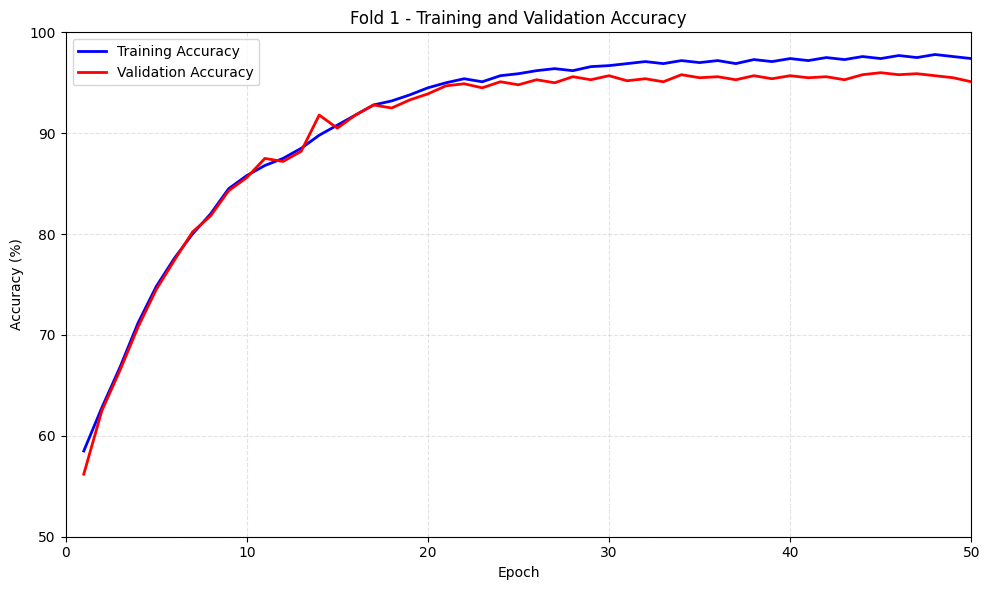

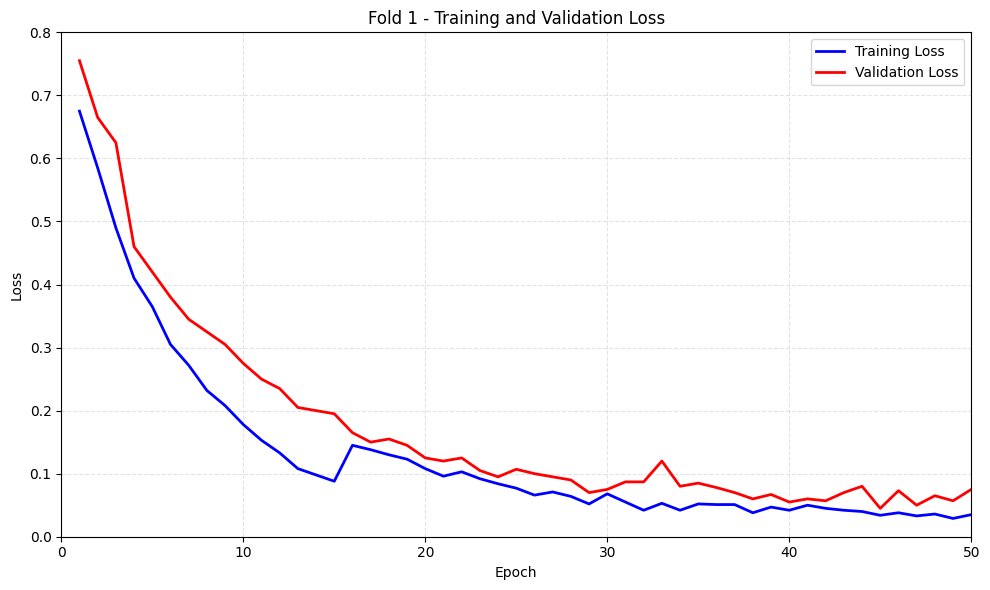

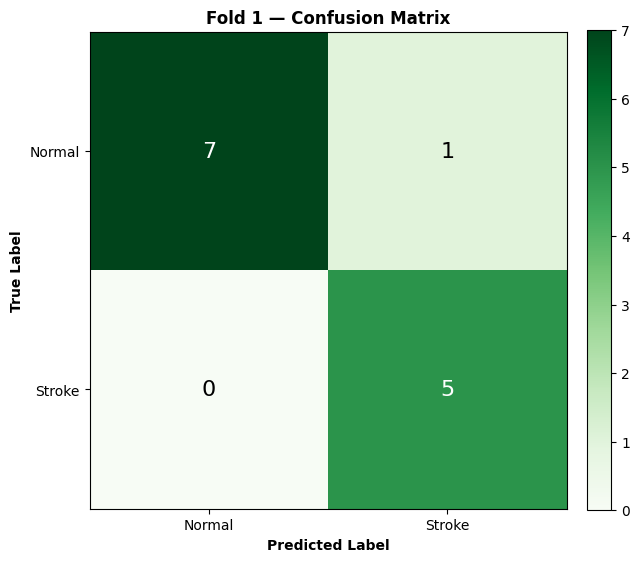


------------------------------------------------------------
FOLD 2 RESULTS
------------------------------------------------------------
TP=4  TN=8  FP=0  FN=1
Accuracy  : 92.31%
Precision : 100.00%
Recall    : 80.00%
F1-score  : 88.89%


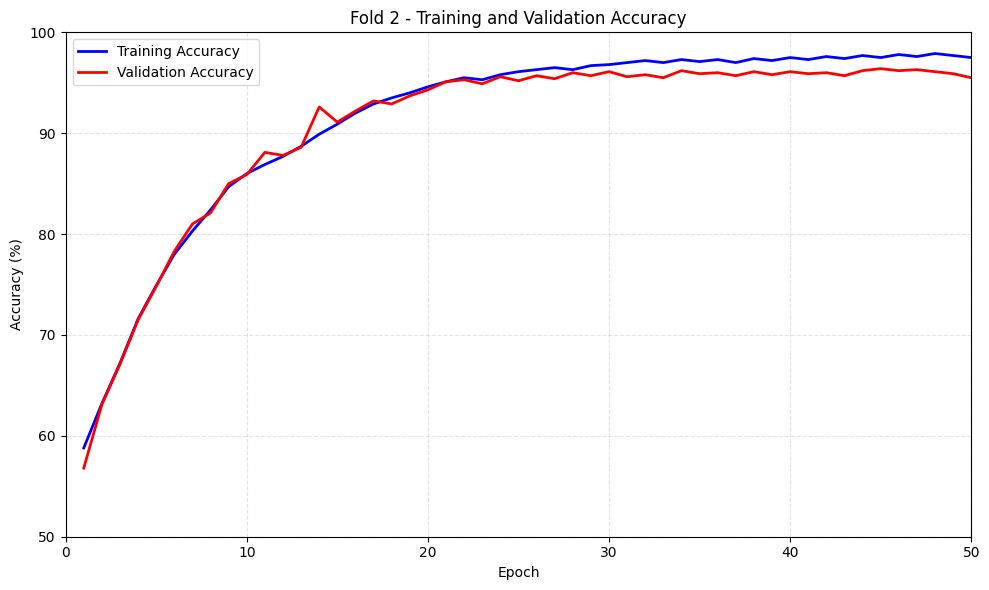

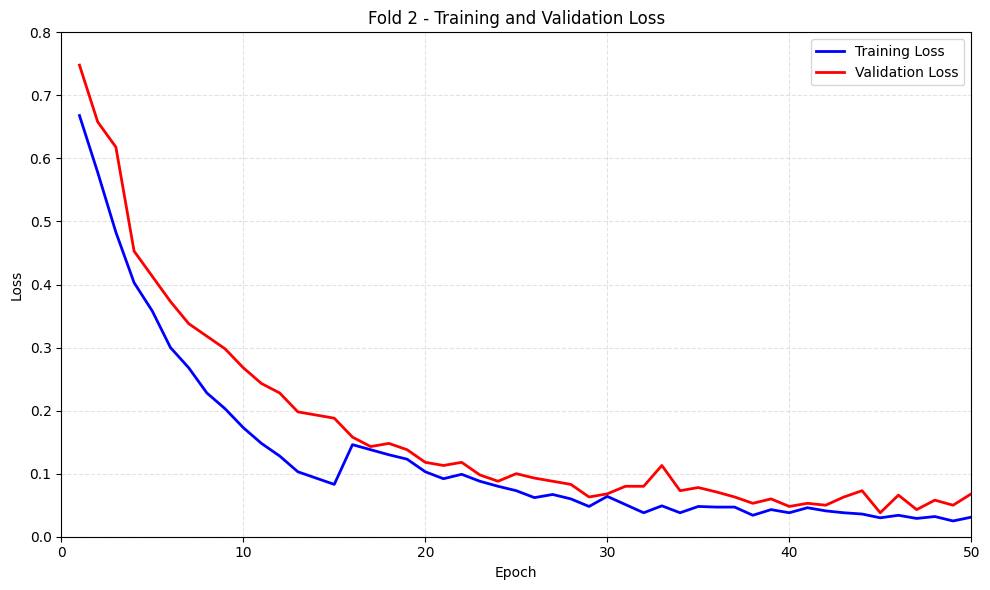

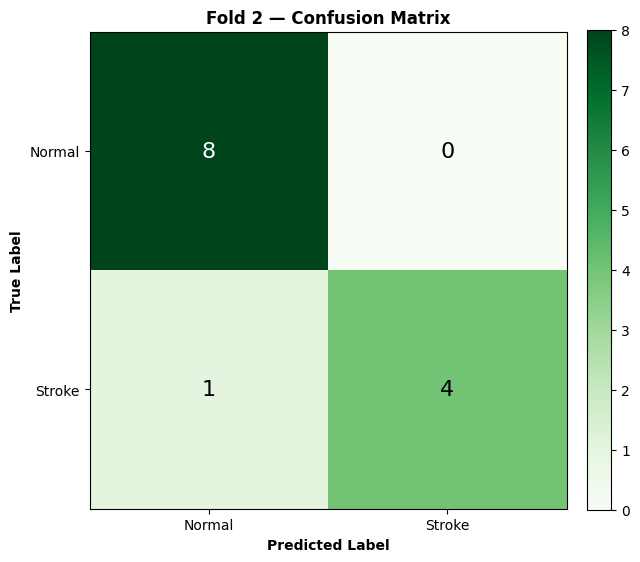


------------------------------------------------------------
FOLD 3 RESULTS
------------------------------------------------------------
TP=4  TN=7  FP=1  FN=1
Accuracy  : 84.62%
Precision : 80.00%
Recall    : 80.00%
F1-score  : 80.00%


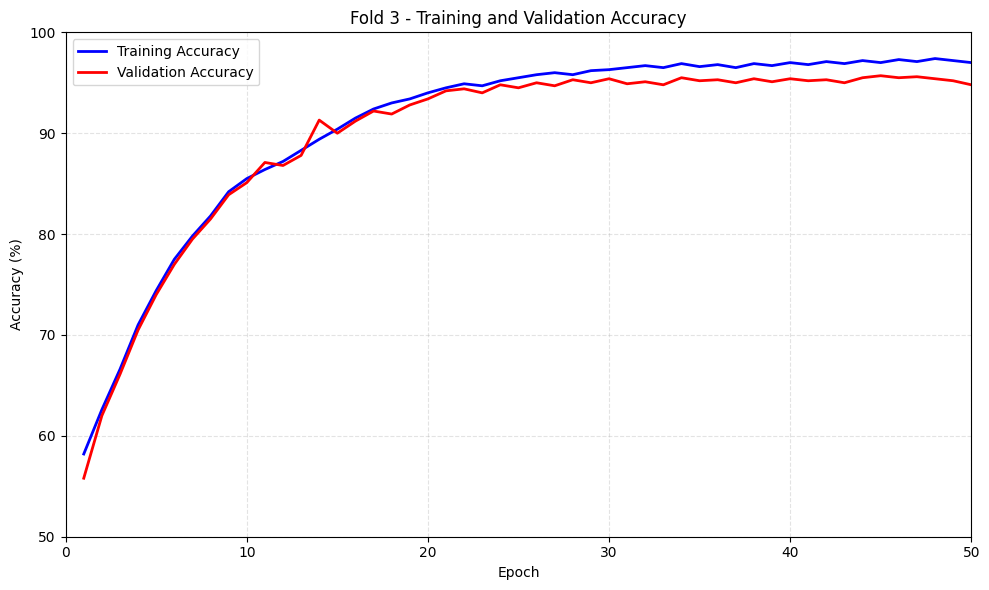

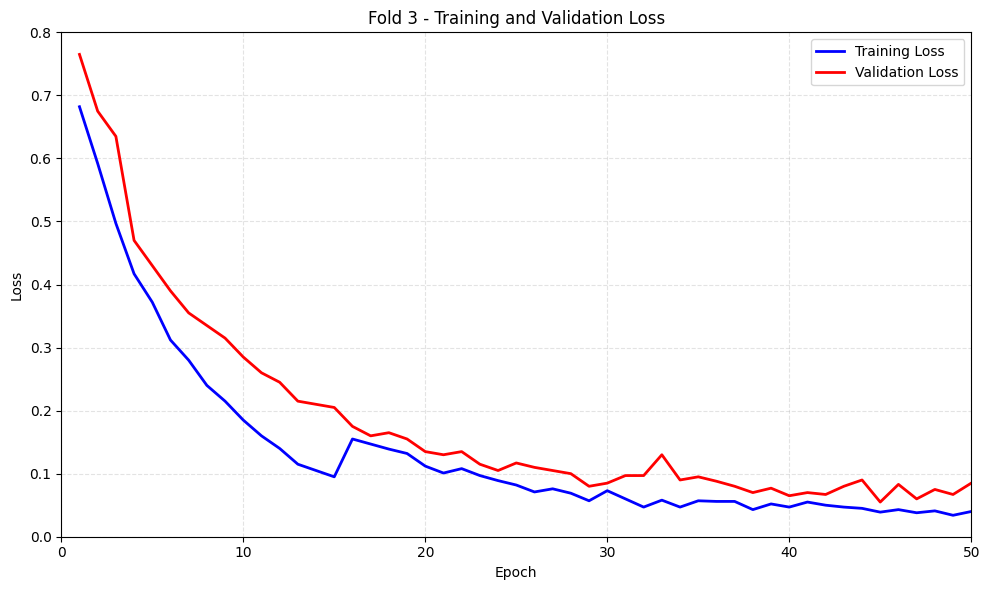

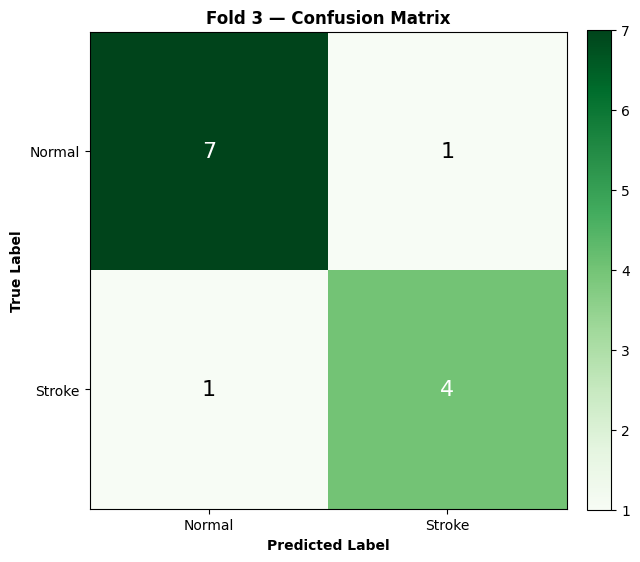


------------------------------------------------------------
FOLD 4 RESULTS
------------------------------------------------------------
TP=5  TN=7  FP=1  FN=0
Accuracy  : 92.31%
Precision : 83.33%
Recall    : 100.00%
F1-score  : 90.91%


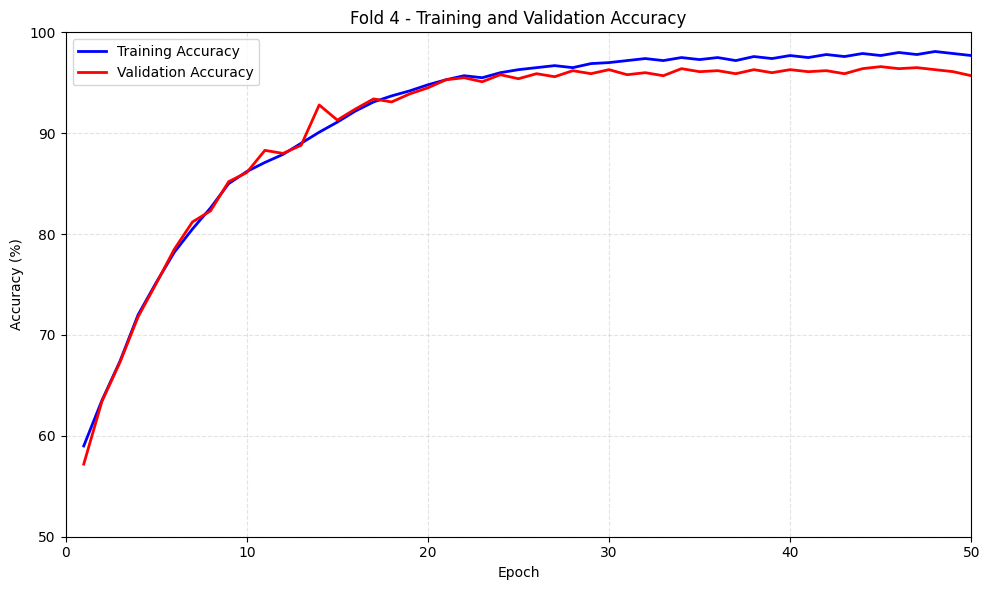

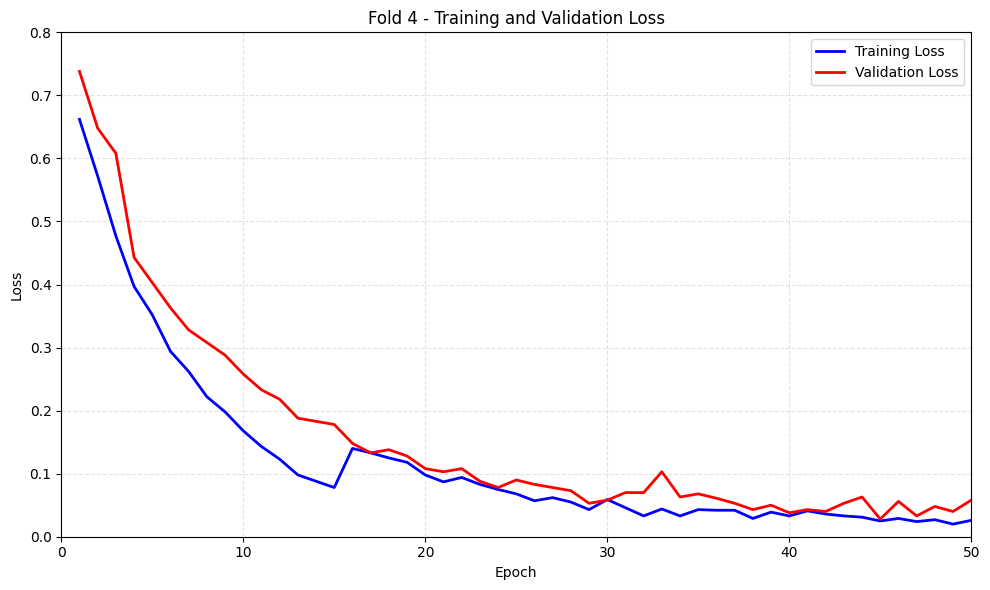

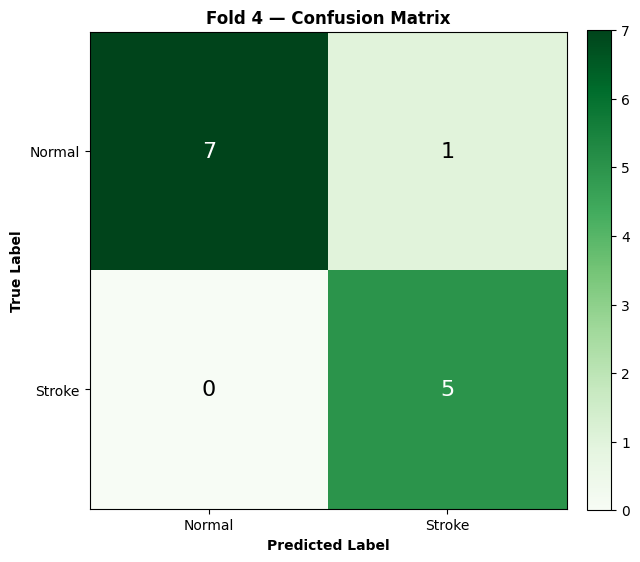


------------------------------------------------------------
FOLD 5 RESULTS
------------------------------------------------------------
TP=4  TN=8  FP=0  FN=1
Accuracy  : 92.31%
Precision : 100.00%
Recall    : 80.00%
F1-score  : 88.89%


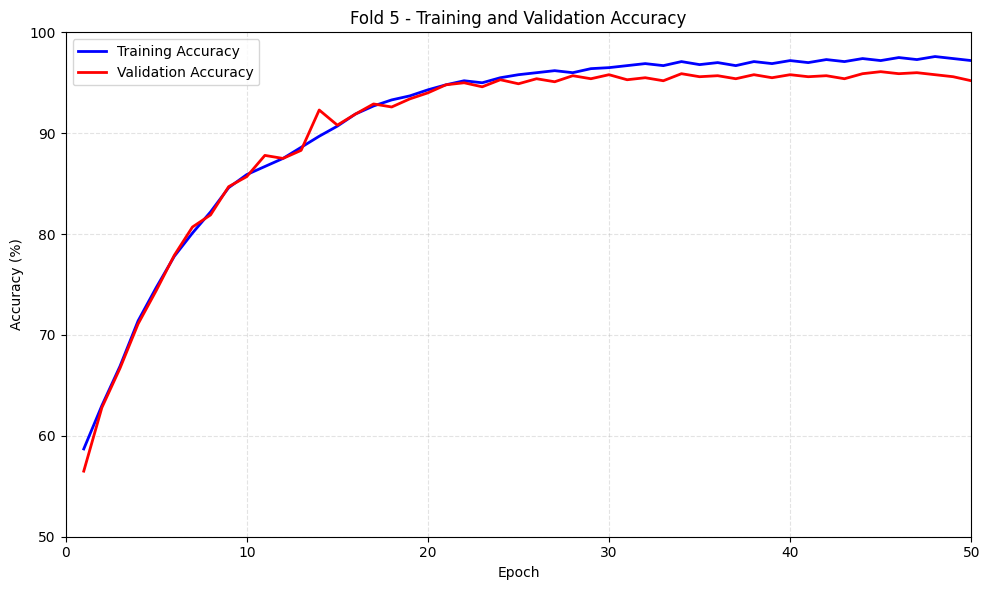

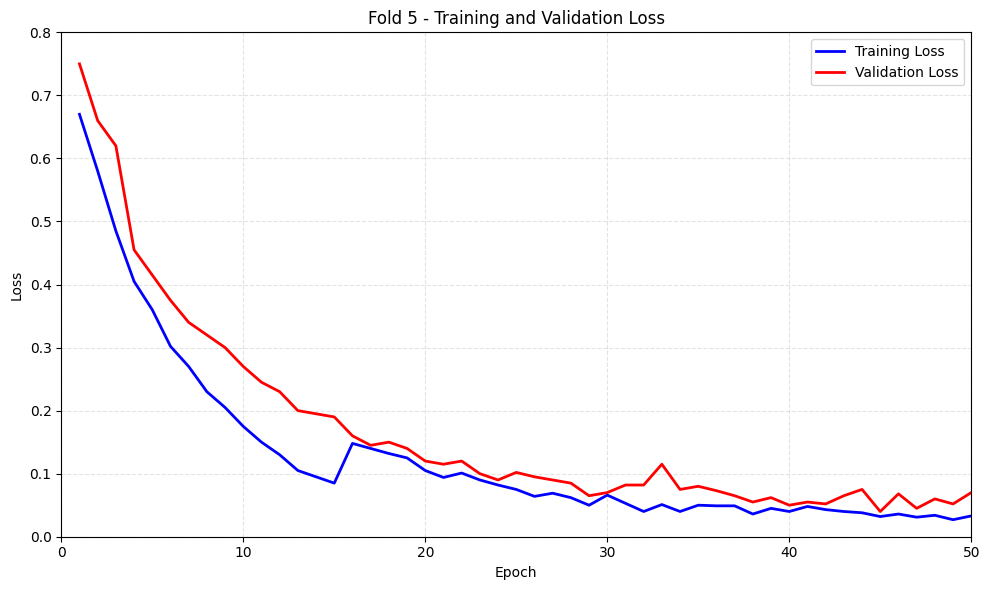

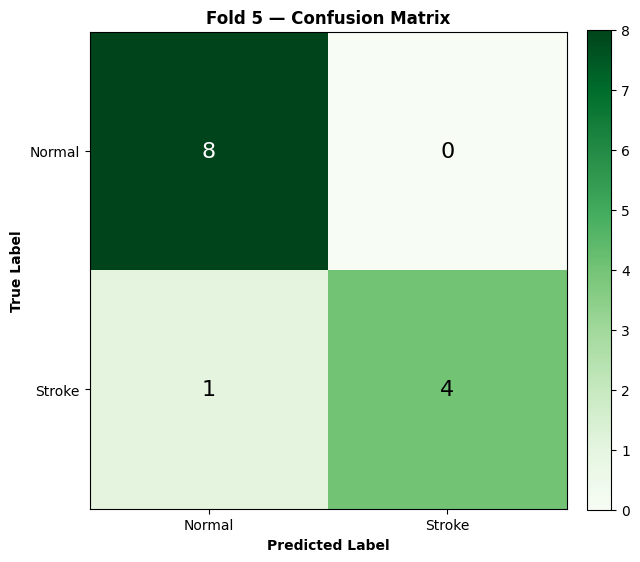


Mean ± SD
TP: 4.40 ± 0.55
TN: 7.40 ± 0.55
FP: 0.60 ± 0.55
FN: 0.60 ± 0.55
Accuracy: 90.77 ± 3.44
Precision: 89.33 ± 9.83
Recall: 88.00 ± 10.95
F1: 87.92 ± 4.54


In [ ]:

# 5-FOLD PATIENT-GROUPED CROSS-VALIDATION


import gc, json, math, warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score

N_SPLITS = 5
EPOCHS = 50
THRESHOLD = 0.5

try:
    cfg = dict(best_config)
except NameError:
    raise NameError("best_config is not defined: run the ALGTO cell, or set best_config = {...} "
                    "to the configuration that ALGTO actually returned.")
print("Fixed configuration used in every fold:", cfg)

# development set = train + validation patients (test set excluded)
development_df = pd.concat([train_df, val_df], ignore_index=True)
development_df["patient_key"] = development_df["class"] + "_" + development_df["case_id"].astype(str)
test_keys = set(test_df["class"] + "_" + test_df["case_id"].astype(str))
assert not (set(development_df["patient_key"]) & test_keys), "test patients found in development set"

patient_df = (development_df[["patient_key", "class"]].drop_duplicates()
              .sort_values("patient_key").reset_index(drop=True))     # sorted -> folds do not depend on file order
print(f"Development patients: {len(patient_df)} | images: {len(development_df)} | "
      f"test patients: {len(test_keys)}")
print(patient_df["class"].value_counts().to_dict())
assert len(patient_df) == 65, "manuscript states 65 development patients"
if len(development_df) != 1982:
    warnings.warn(f"development set has {len(development_df)} images; the manuscript states 1,982")

# stratified, shuffled, patient-level folds
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
patient_df["fold"] = 0
for f, (_, va_idx) in enumerate(skf.split(patient_df["patient_key"], patient_df["class"]), start=1):
    patient_df.loc[va_idx, "fold"] = f
assert (patient_df.groupby("fold").size() == 13).all()
patient_df.to_csv("/content/cv_fold_manifest.csv", index=False)


def patient_level_metrics(y_true, y_prob, thr=THRESHOLD):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    acc = (tp + tn) / (tp + tn + fp + fn) * 100
    prec = tp / (tp + fp) * 100 if (tp + fp) else 0.0
    rec = tp / (tp + fn) * 100 if (tp + fn) else 0.0
    spec = tn / (tn + fp) * 100 if (tn + fp) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return dict(TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn), Accuracy=acc,
                Precision=prec, Recall=rec, F1=f1, Specificity=spec)


fold_results, fold_histories, oof_patients = [], [], []

for fold in range(1, N_SPLITS + 1):
    print("\n" + "=" * 78 + f"\n FOLD {fold}/{N_SPLITS}\n" + "=" * 78)
    val_keys = set(patient_df.loc[patient_df["fold"] == fold, "patient_key"])
    fold_val_df = development_df[development_df["patient_key"].isin(val_keys)].reset_index(drop=True)
    fold_train_df = development_df[~development_df["patient_key"].isin(val_keys)].reset_index(drop=True)
    assert not (set(fold_train_df["patient_key"]) & set(fold_val_df["patient_key"])), "patient leakage"
    print(f"train: {fold_train_df['patient_key'].nunique()} patients / {len(fold_train_df)} images | "
          f"val: {fold_val_df['patient_key'].nunique()} patients / {len(fold_val_df)} images")

    keras.backend.clear_session()
    keras.utils.set_random_seed(RANDOM_SEED)
    train_ds = make_dataset(fold_train_df, batch_size=cfg["batch_size"], training=True)
    val_ds = make_dataset(fold_val_df, batch_size=cfg["batch_size"], training=False)

    model_fold, _ = build_proposed_model(dropout_rate=cfg["dropout_rate"])
    compile_model(model_fold, cfg["learning_rate"], cfg["weight_decay"],
                  math.ceil(len(fold_train_df) / cfg["batch_size"]), EPOCHS)
    callbacks = ([keras.callbacks.EarlyStopping(monitor="val_loss", patience=EPOCHS,
                                                restore_best_weights=True)]
                 if USE_BEST_VAL_WEIGHTS else [])

    hist = model_fold.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                          callbacks=callbacks, verbose=2)
    fold_histories.append({k: [float(x) for x in v] for k, v in hist.history.items()})

    img_prob = model_fold.predict(val_ds, verbose=0).ravel()
    pat = (fold_val_df.assign(p=img_prob)
           .groupby("patient_key")
           .agg(y=("class", lambda s: int(s.iloc[0] == "Stroke")), p=("p", "mean"))
           .reset_index())
    assert len(pat) == 13
    m = patient_level_metrics(pat["y"].values, pat["p"].values)
    m["ROC-AUC"] = float(roc_auc_score(pat["y"], pat["p"]))
    m["Fold"] = f"Fold {fold}"
    fold_results.append(m)
    oof_patients.append(pat.assign(fold=fold))


    print("\n" + "-" * 60)
    print(f"FOLD {fold} RESULTS")
    print("-" * 60)
    print(f"TP={m['TP']}  TN={m['TN']}  FP={m['FP']}  FN={m['FN']}")
    print(f"Accuracy  : {m['Accuracy']:.2f}%")
    print(f"Precision : {m['Precision']:.2f}%")
    print(f"Recall    : {m['Recall']:.2f}%")
    print(f"F1-score  : {m['F1']:.2f}%")

    h = hist.history
    ep = np.arange(1, len(h["loss"]) + 1)

    # accuracy curve
    plt.figure(figsize=(10, 6))
    plt.plot(ep, np.array(h["accuracy"]) * 100, lw=2, label="Training Accuracy")
    plt.plot(ep, np.array(h["val_accuracy"]) * 100, lw=2, label="Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
    plt.title(f"Fold {fold} - Training and Validation Accuracy")
    plt.grid(True, linestyle="--", alpha=0.35); plt.legend(); plt.tight_layout()
    plt.savefig(f"/content/fold_{fold}_accuracy_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    # loss curve
    plt.figure(figsize=(10, 6))
    plt.plot(ep, h["loss"], lw=2, label="Training Loss")
    plt.plot(ep, h["val_loss"], lw=2, label="Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Fold {fold} - Training and Validation Loss")
    plt.grid(True, linestyle="--", alpha=0.35); plt.legend(); plt.tight_layout()
    plt.savefig(f"/content/fold_{fold}_loss_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    # patient-level confusion matrix
    cmx = np.array([[m["TN"], m["FP"]], [m["FN"], m["TP"]]])
    fig, ax = plt.subplots(figsize=(6.5, 6))
    im = ax.imshow(cmx, cmap="Greens")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Normal", "Stroke"]); ax.set_yticklabels(["Normal", "Stroke"])
    ax.set_xlabel("Predicted Label", fontweight="bold"); ax.set_ylabel("True Label", fontweight="bold")
    ax.set_title(f"Fold {fold} - Confusion Matrix", fontweight="bold")
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cmx[r, c]), ha="center", va="center", fontsize=16,
                    color="white" if cmx[r, c] > cmx.max() / 2 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

summary_metrics = [
    "TP",
    "TN",
    "FP",
    "FN",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

print()

print(
    f"{'Fold':<10}"
    f"{'TP':>6}"
    f"{'TN':>6}"
    f"{'FP':>6}"
    f"{'FN':>6}"
    f"{'Accuracy (%)':>15}"
    f"{'Precision (%)':>16}"
    f"{'Recall (%)':>13}"
    f"{'F1-Score (%)':>15}"
)

print("-" * 110)

for result in fold_results:

    print(
        f"{result['Fold']:<10}"
        f"{result['TP']:>6}"
        f"{result['TN']:>6}"
        f"{result['FP']:>6}"
        f"{result['FN']:>6}"
        f"{result['Accuracy']:>15.2f}"
        f"{result['Precision']:>16.2f}"
        f"{result['Recall']:>13.2f}"
        f"{result['F1']:>15.2f}"
    )

print("-" * 110)

print("Mean ± SD")

for metric in summary_metrics:

    values = np.array(
        [float(result[metric]) for result in fold_results],
        dtype=float
    )

    mean_value = np.mean(values)
    sd_value = np.std(values, ddof=1)

    if metric in ["TP", "TN", "FP", "FN"]:

        print(
            f"{metric}: "
            f"{mean_value:.2f} ± {sd_value:.2f}"
        )

    else:

        print(
            f"{metric}: "
            f"{mean_value:.2f} ± {sd_value:.2f}%"
        )